In [1]:
import pickle
import mocet
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))
basis = np.load("data/basis.npy")
basis_params = np.load("data/basis_params.npy")

subject_pool = {
    'sub-003': {'ses-07R': ([1, 2, 3, 4, 5], False), 'ses-13R': ([1, 2, 4, 5, 6], False)},
    'sub-004': {'ses-07R': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-005': {'ses-07': ([1, 2, 3, 4, 5, 6], True)},
    'sub-006': {'ses-07R': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-008': {'ses-07R': ([2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-009': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 5, 6], False)},
    'sub-010': {'ses-07': ([1, 2, 3, 4, 5], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-011': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-012': {'ses-07': ([1, 2, 4, 5, 6], False)},
    'sub-013': {'ses-07': ([1, 2, 3, 4], False)},
    'sub-014': {'ses-07': ([2, 3, 4, 5, 6], False)},
    'sub-015': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-016': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-017': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5], False)},
    'sub-018': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-020': {'ses-07': ([1, 2, 3, 4, 5, 6], False), 'ses-13': ([1, 2, 3, 4, 5, 6], False)},
    'sub-021': {'ses-07': ([1, 2, 4, 5, 6], False), 'ses-13': ([1, 2, 4, 5, 6], False)},
    'sub-JJY': {'ses-07': ([1, 2, 3, 4, 5, 6], False)},
    'sub-KMY': {'ses-07': ([1, 2, 3, 4, 5, 6], False)},
    'sub-PJW': {'ses-07': ([1, 2, 3, 4, 6], True)},
    'sub-PBJ': {'ses-07': ([1, 2, 3, 4, 5], False)}
}

history_onset = {'sub-005': [28.66, 29.32, 28.12, 33.7, 36.1, 27.46], 'sub-PJW': [35, 30.8, 28.66, 26.58, None, 27.42]}

task_duration = 816
calibration_onsets = [1, 494]
calibration_points = [24, 12]
interval = 1.6
calibration_offset_start = 0.5
calibration_offset_end = -0.5
t_cal = 0

motion_param_labels = ['trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

index = 0
validation_errors = []
pupil_displacement = []
pupil_displacement_model = []

for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(key)

    root = f'../../_DATA/{subject}/{session}'
    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'

    runs, history_loss = subject_pool[subject][session]
    if history_loss:
        start = history_onset[subject][r - 1]
    else:
        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
        start, _, _ = mocet.utils.get_avotec_history(history_fname)

    pupil_data, pupil_timestamps, pupil_confidence, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                                                   data_fname,
                                                                                                   start=start,
                                                                                                   duration=task_duration)
    offset = calibration_onsets[t_cal]
    calibration_pupils = []
    for i in np.arange(calibration_points[t_cal]):
        start = (offset + i) * interval + calibration_offset_start
        end = (offset + i + 1) * interval + calibration_offset_end
        log_effective = np.logical_and(pupil_timestamps >= start * 1000, pupil_timestamps < end * 1000)
        calibration_pupils.append([np.nanmean(pupil_data[log_effective, 0]),
                                   np.nanmean(pupil_data[log_effective, 1])])
    calibration_pupils = np.array(calibration_pupils).reshape(2, 12, 2).mean(axis=0)

    basis_similarity = []
    for i in range(len(basis)):
        basis_similarity.append(np.mean(np.sqrt(np.sum((basis[i] - calibration_pupils) ** 2, axis=-1))))
    basis_idx = np.argmin(basis_similarity)

    fmriprep_confounds = pd.read_csv(confounds_fname, delimiter='\t')
    motion_params = fmriprep_confounds[motion_param_labels]
    motion_params = np.nan_to_num(motion_params)
    motion_params = motion_params - motion_params[0, :]

    displacement = mocet.simulation.generate(motion_params, basis_params[basis_idx], save_directory='', index=index, render=False)
    validation_errors.append(testable_data[key][3])
    pupil_displacement.append(testable_data[key][4])
    pupil_displacement_model.append(displacement)
    index += 510

('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-5')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-4')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-1')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-3')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-6')
('sub-005', 'ses-07', 'task-mcHERDING', 'run-1')
('sub-005', 'ses-07', 'task-mcHERDING', 'run-3')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-3')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-4')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-5')
('sub

In [2]:
simulation_log_fname = f'data/simulation_log.csv'
simulation_log = pd.read_csv(simulation_log_fname)
simulation_pupil_data = simulation_log[["center_x","center_y","diameter_px"]].to_numpy()
print(simulation_pupil_data.shape, 510*len(list(testable_data.keys())))
key_simulation_pupil_data = {}
key_simulation_pupil_size = {}
k = 0
duration_tr = 510
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    data = simulation_pupil_data[k*duration_tr:(k+1)*duration_tr,:]
    for i in range(510):
        if data[i, 0] == -1:
            data[i,:] = data[i-1,:]
    key_simulation_pupil_data[key] = data[:,:2]
    key_simulation_pupil_size[key] = data[:,2]
    k += 1

(56610, 3) 56610


In [3]:
px_per_deg = 78.43
validation_error_model = []
for key in list(testable_data.keys()):
    pupil_data = key_simulation_pupil_data[key]
    t_cal = 0
    offset = 1
    calibration_pupils = []
    for i in np.arange(24):
        start = (offset+i)
        end = (offset+i+1)
        calibration_pupils.append([np.nanmean(pupil_data[start:end,0]),
                                  np.nanmean(pupil_data[start:end,1])])
    calibration_pupils = np.array(calibration_pupils)
    calibration_pupils = (calibration_pupils[:12,:] + calibration_pupils[12:,:]) / 2
    
    repeat = False
    calibrator = mocet.EyetrackingCalibration(repeat=repeat, method='linear')
    calibrator.fit(calibration_pupils[:, 0], calibration_pupils[:, 1])
    gaze_coordinates = calibrator.transform(pupil_data)
    
    t_val = 1
    RMSE = []
    offset = 494
    for i in np.arange(12):
        ref_x, ref_y = calibrator.reference(i)
        start = (offset+i)
        end = (offset+i+1)
        data_x = np.nanmean(gaze_coordinates[start:end,0])
        data_y = np.nanmean(gaze_coordinates[start:end,1])
        RMSE.append(np.sqrt((ref_x-data_x)**2 + (ref_y-data_y)**2))
    validation_error = np.nanmean(RMSE)/px_per_deg
    validation_error_model.append(validation_error)

PearsonRResult(statistic=0.8547060451397932, pvalue=8.174585215138179e-33)
0.6859133671186196 0.2932889409404068


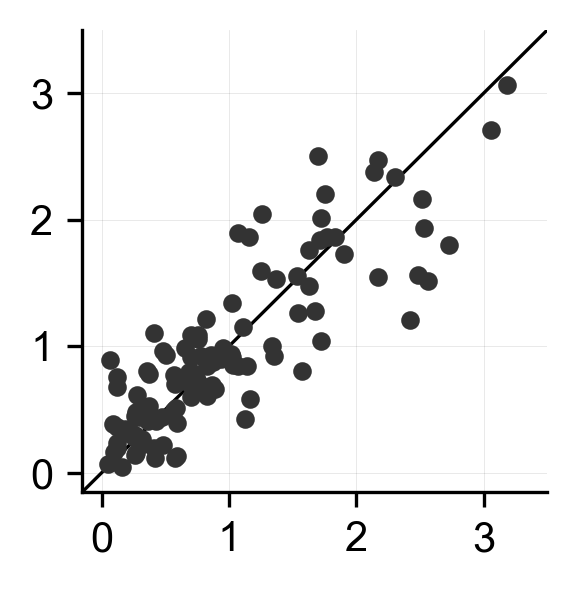

In [4]:
plt.style.use('default')
from scipy.stats import linregress, pearsonr
y = np.array(pupil_displacement)
x = np.array(pupil_displacement_model)*1000 # meter to mm
print(pearsonr(x,y))
slope, intercept, r, p, stderr = linregress(x, y)
print(slope, intercept)
#p = np.polyfit(np.log(x), y, 1)
# y = p[0] log(x) + p[1]
#print(slope, intercept)
#print(p[0]*np.log(0.5) + p[1], p[0]*np.log(1.0) + p[1])
x_range = np.linspace(np.min(x)-2, np.max(x)+5, 100)

fig, ax = plt.subplots(1,1,figsize=(2,2), dpi=300)

for xx in range(5):
    ax.axvline(x=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    ax.axhline(y=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)

ax.scatter(x, y, s=12, c='#333333', zorder=100)
ax.plot(x_range, x_range, linestyle='-', c='k', lw=0.8, zorder=2)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylim(-0.15, 3.5)
ax.set_yticks([0,1,2,3])
ax.set_xlim(-0.15, 3.5)
ax.set_xticks([0,1,2,3])
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")

TtestResult(statistic=-14.47724714022947, pvalue=3.117288567516876e-27, df=110)
PearsonRResult(statistic=0.936555591947592, pvalue=1.9218596147973145e-51)
1.2020781505812805 1.5257351331869264


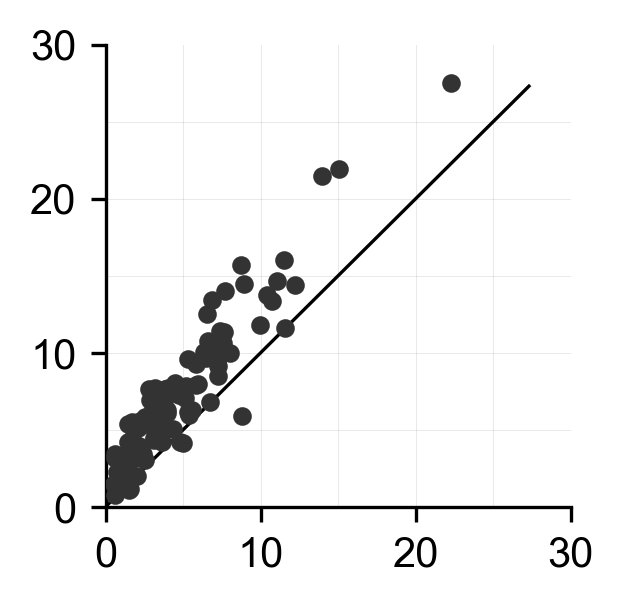

In [5]:
plt.style.use('default')
from scipy.stats import linregress, pearsonr, ttest_rel
y = np.array(validation_errors)
x = np.array(validation_error_model) 
print(ttest_rel(x,y))
print(pearsonr(x,y))
slope, intercept, r, p, stderr = linregress(x, y)
print(slope, intercept)
#p = np.polyfit(np.log(x), y, 1)
# y = p[0] log(x) + p[1]
#print(slope, intercept)
#print(p[0]*np.log(0.5) + p[1], p[0]*np.log(1.0) + p[1])
x_range = np.linspace(np.min(x)-2, np.max(x)+5, 100)

fig, ax = plt.subplots(1,1,figsize=(2,2), dpi=300)
# 
for xx in [5,10,15,20,25]:
    ax.axvline(x=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)
    ax.axhline(y=xx, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=0)

ax.scatter(x, y, s=12, c='#333333', zorder=100)
ax.plot(x_range, x_range, linestyle='-', c='k', lw=0.8, zorder=2)

ax.spines[['right', 'top']].set_visible(False)
ax.set_ylim(0, 30)
#ax.set_yticks([0,1,2,3])
ax.set_xlim(0, 30)
#ax.set_xticks([0,1,2,3])
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")

In [3]:
from sklearn.metrics import r2_score
from scipy import interpolate
from scipy.stats import pearsonr

pupil_x_r = []
pupil_y_r = []
key_list = list(testable_data.keys())
for key in key_list:
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    root = f'../../_DATA/{subject}/{session}'
    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt' 
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
    _, history_loss = subject_pool[subject][session]
    if history_loss: 
        start = history_onset[subject][r-1]
    else:
        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
        start, _, _ = mocet.utils.get_avotec_history(history_fname)
    
    # log, data, confound, start
    pupil_data, pupil_timestamps, _, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                             data_fname,
                                                                             start=start,
                                                                             duration=task_duration)

    pupil_data_x = pupil_data[:,0] - np.mean(pupil_data[:int(1.6*25*60),0])
    pupil_data_y = pupil_data[:,1] - np.mean(pupil_data[:int(1.6*25*60),1])
    
    pupil_simulation_x = key_simulation_pupil_data[key][:,0] - np.mean(key_simulation_pupil_data[key][:25,0])
    pupil_simulation_y = key_simulation_pupil_data[key][:,1] - np.mean(key_simulation_pupil_data[key][:25,1])
    
    # downsampling
    x = np.arange(0, len(pupil_data_x))
    f = interpolate.interp1d(x, pupil_data_x)
    xnew = np.linspace(0, len(pupil_data_x) - 1, len(pupil_simulation_x))
    pupil_data_x_downsample = f(xnew)
    f = interpolate.interp1d(x, pupil_data_y)
    xnew = np.linspace(0, len(pupil_data_y) - 1, len(pupil_simulation_y))
    pupil_data_y_downsample = f(xnew)
    
    pupil_x_r.append(pearsonr(pupil_data_x_downsample[26:494],
                               pupil_simulation_x[26:494])[0])
    pupil_y_r.append(pearsonr(pupil_data_y_downsample[26:494],
                               pupil_simulation_y[26:494])[0])
    print(key, pupil_x_r[-1], pupil_y_r[-1])
    

pupil_x_r_group = {}
pupil_y_r_group = {}
for k in range(len(key_list)):
    key = key_list[k]
    print(key)
    subject = key[0]
    if not pupil_x_r_group.keys().__contains__(subject):
        pupil_x_r_group[subject] = []
        pupil_y_r_group[subject] = []
    
    pupil_x_r_group[subject].append(pupil_x_r[k])
    pupil_y_r_group[subject].append(pupil_y_r[k])

subjects_x_r2 = []
subjects_y_r2 = []
for key in pupil_x_r_group.keys():
    subjects_x_r2.append(np.mean(pupil_x_r_group[key], axis=0))
    subjects_y_r2.append(np.mean(pupil_y_r_group[key], axis=0))

('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1') 0.8538676421171533 0.9245442195807729
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2') 0.7932056724264441 0.8837420025138905
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3') 0.6566078961440407 0.8924519345117027
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1') 0.6145910400615755 0.7093774716780292
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2') 0.541661153208416 0.7853615011748469
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4') 0.6279587328039071 0.6072954888845723
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-5') 0.5417305367219298 0.9393404811180945
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-1') 0.3666125882947854 0.8295864547793597
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-2') 0.36058235338132844 0.7170658429161274
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-4') 0.3448096464454252 0.835792183223391
('sub-004', 'ses-13', 'task-mcHERDING', 'run-1') 0.48706983812404325 0.9438774703864438
('sub-004', 'ses-13', 'task-mcHER

In [5]:
print(np.mean(pupil_x_r), np.mean(pupil_y_r), np.median(pupil_x_r), np.median(pupil_y_r))

0.46040636276712665 0.8013359294579889 0.502041013150566 0.8506588828823383


In [9]:
null_simulation_log_fname = f'data/null_simulation_log.csv'
null_simulation_log = pd.read_csv(null_simulation_log_fname)
null_simulation_pupil = null_simulation_log[["center_x", "center_y", "diameter_px"]].to_numpy()

print(null_simulation_pupil.shape)
duration_tr = 510

null_simulation_pupil_data = []
null_simulation_pupil_size = []
k = 0
n_iteration = 100
for key in testable_data.keys():
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(k, subject, session, task, run, r)
    
    subject_data = []
    subject_size = []
    for i in range(n_iteration):
        data = null_simulation_pupil[k*duration_tr:(k+1)*duration_tr,:]
        for i in range(510):
            if data[i, 0] == -1:
                data[i,:] = data[i-1,:]
                print(k*510 + i)
        subject_data.append(data[:,:2])
        subject_size.append(data[:,2])
        k += 1
    null_simulation_pupil_data.append(subject_data)
    null_simulation_pupil_size.append(subject_size)
    
null_simulation_pupil_data = np.array(null_simulation_pupil_data)
null_simulation_pupil_size = np.array(null_simulation_pupil_size)

(5661000, 3)
0 sub-003 ses-07R task-mcHERDING run-1 1
100 sub-003 ses-07R task-mcHERDING run-2 2
200 sub-003 ses-07R task-mcHERDING run-3 3
300 sub-003 ses-13R task-mcHERDING run-1 1
400 sub-003 ses-13R task-mcHERDING run-2 2
500 sub-003 ses-13R task-mcHERDING run-4 4
600 sub-003 ses-13R task-mcHERDING run-5 5
700 sub-004 ses-07R task-mcHERDING run-1 1
800 sub-004 ses-07R task-mcHERDING run-2 2
900 sub-004 ses-07R task-mcHERDING run-4 4
1000 sub-004 ses-13 task-mcHERDING run-1 1
1100 sub-004 ses-13 task-mcHERDING run-3 3
1200 sub-004 ses-13 task-mcHERDING run-6 6
1300 sub-005 ses-07 task-mcHERDING run-1 1
1400 sub-005 ses-07 task-mcHERDING run-3 3
1500 sub-006 ses-07R task-mcHERDING run-1 1
1600 sub-006 ses-07R task-mcHERDING run-2 2
1700 sub-006 ses-07R task-mcHERDING run-3 3
1800 sub-006 ses-07R task-mcHERDING run-4 4
1900 sub-006 ses-07R task-mcHERDING run-5 5
2000 sub-006 ses-07R task-mcHERDING run-6 6
2100 sub-006 ses-13 task-mcHERDING run-1 1
2200 sub-006 ses-13 task-mcHERDING ru

In [10]:

null_r_x = []
null_r_y = []

key_list = list(testable_data.keys())
for k in range(len(key_list)):
    key = key_list[k]
    subject = key[0]
    session = key[1]
    task = key[2]
    run = key[3]
    r = int(run[4])
    print(key)
    
    root = f'../../_DATA/{subject}/{session}'
    log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
    data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt' 
    confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'
    _, history_loss = subject_pool[subject][session]
    if history_loss: 
        start = history_onset[subject][r-1]
    else:
        history_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_his.txt'
        start, _, _ = mocet.utils.get_avotec_history(history_fname)
    
    # log, data, confound, start
    pupil_data, pupil_timestamps, _, pupil_diameter = mocet.utils.clean_avotec_data(log_fname,
                                                                             data_fname,
                                                                             start=start,
                                                                             duration=task_duration)

    pupil_data_x = pupil_data[:,0] - np.mean(pupil_data[:int(1.6*25*60),0])
    pupil_data_y = pupil_data[:,1] - np.mean(pupil_data[:int(1.6*25*60),1])
    
    # downsampling
    x = np.arange(0, len(pupil_data_x))
    f = interpolate.interp1d(x, pupil_data_x)
    xnew = np.linspace(0, len(pupil_data_x) - 1, 510)
    pupil_data_x_downsample = f(xnew)
    f = interpolate.interp1d(x, pupil_data_y)
    xnew = np.linspace(0, len(pupil_data_y) - 1, 510)
    pupil_data_y_downsample = f(xnew)
    
    for i in range(n_iteration):
        pupil_simulation_x = null_simulation_pupil_data[k,i,:,0] - np.mean(null_simulation_pupil_data[k,i,:25,0])
        pupil_simulation_y = null_simulation_pupil_data[k,i,:,1] - np.mean(null_simulation_pupil_data[k,i,:25,1])
    
        null_r_x.append(pearsonr(pupil_data_x_downsample[26:494],
                                   pupil_simulation_x[26:494])[0])
        null_r_y.append(pearsonr(pupil_data_y_downsample[26:494],
                                   pupil_simulation_y[26:494])[0])

null_r_x = np.array(null_r_x)
null_r_y = np.array(null_r_y)
np.save('data/null_r_x.npy', null_r_x)
np.save('data/null_r_y.npy', null_r_y)

('sub-003', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-003', 'ses-07R', 'task-mcHERDING', 'run-3')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-1')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-2')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-4')
('sub-003', 'ses-13R', 'task-mcHERDING', 'run-5')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-004', 'ses-07R', 'task-mcHERDING', 'run-4')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-1')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-3')
('sub-004', 'ses-13', 'task-mcHERDING', 'run-6')
('sub-005', 'ses-07', 'task-mcHERDING', 'run-1')
('sub-005', 'ses-07', 'task-mcHERDING', 'run-3')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-1')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-2')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-3')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-4')
('sub-006', 'ses-07R', 'task-mcHERDING', 'run-5')
('sub

0.046216216216216216
0.013693693693693694


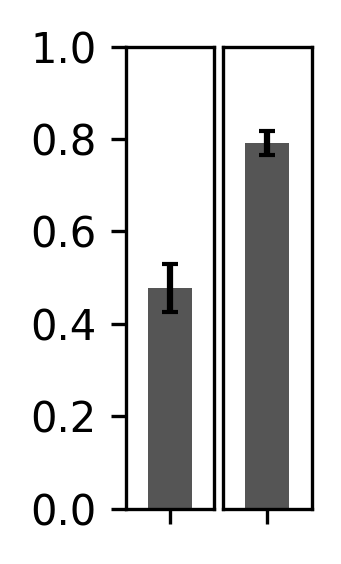

In [56]:
print(np.sum(np.mean(subjects_x_r2) < null_r_x)/ len(null_r_x))
print(np.sum(np.mean(subjects_y_r2) < null_r_y)/ len(null_r_y))

from scipy.stats import sem
fig, axes = plt.subplots(1,2,figsize=(0.8,2), dpi=300, sharex=True)
axes[0].bar([0], np.mean(subjects_x_r2, axis=0), yerr=sem(subjects_x_r2, axis=0), width=1, capsize=2, color='#555555')
axes[1].bar([0], np.mean(subjects_y_r2, axis=0), yerr=sem(subjects_y_r2, axis=0), width=1, capsize=2, color='#555555')
for ax in axes:
    ax.set_xticks([0])
    ax.set_xticklabels([""])
    ax.set_xlim(-1, 1)
    ax.set_ylim(0, 1)
ax.set_ylim(0, 1.0)
axes[0].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
axes[1].set_yticks([])
plt.subplots_adjust(wspace=0.1)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")

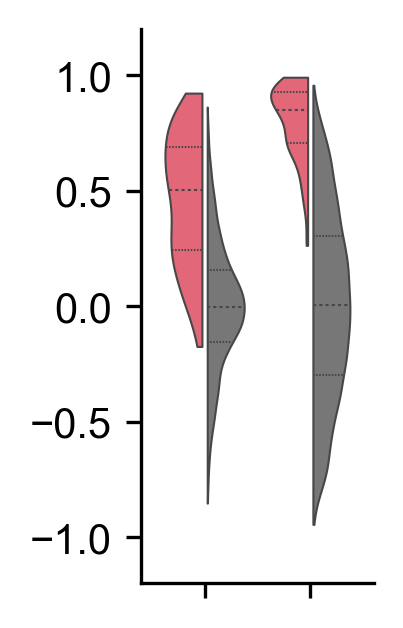

In [36]:
import seaborn as sns
import matplotlib


# Create a DataFrame for seaborn
data_x = pd.DataFrame({
    'score': np.concatenate([pupil_x_r, null_r_x]),
    'type': ['actual'] * len(pupil_x_r) + ['null'] * len(null_r_x),
    'coordinate': ['x'] * (len(pupil_x_r) + len(null_r_x))
})

data_y = pd.DataFrame({
    'score': np.concatenate([pupil_y_r, null_r_y]),
    'type': ['actual'] * len(pupil_y_r) + ['null'] * len(null_r_y),
    'coordinate': ['y'] * (len(pupil_y_r) + len(null_r_y))
})

data = pd.concat([data_x, data_y])

# Plot
fig, ax = plt.subplots(figsize=(1, 2.4), dpi=300)

sns.violinplot(ax=ax, x='coordinate', y='score', hue='type', 
               data=data, split=True, inner="quart", palette={"actual": "#f6546a", "null": "#777777"}, 
               linewidth=0.5, cut=0, scale='width', width=0.7)

# Adjust x-ticks
ax.set_xticks([0, 1])
ax.set_xticklabels(['', ''])
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(-1.2, 1.2)
ax.legend([], frameon=False)
ax.set_xlabel(None)
ax.set_ylabel(None)

# Adjust the position of the violins
delta = 0.025
for ii, item in enumerate(ax.collections):
    if isinstance(item, matplotlib.collections.PolyCollection):
        path, = item.get_paths()
        vertices = path.vertices
        if ii % 2:  # -> to right
            vertices[:, 0] += delta
        else:  # -> to left
            vertices[:, 0] -= delta        
for i, line in enumerate(ax.get_lines()):
    line.get_path().vertices[:, 0] += delta if i // 3 % 2 else -delta
    
ax.spines[['right', 'top']].set_visible(False)
plt.subplots_adjust(wspace=0.1)
for tick in ax.get_yticklabels():
    tick.set_fontname("Arial")
for tick in ax.get_xticklabels():
    tick.set_fontname("Arial")
plt.show()

In [54]:
minimum_p_value = 10e-12

n_iterations = 100
p_values_x = []
p_values_y = []
for i in range(len(pupil_x_r)):
    actual = pupil_x_r[i]
    nulls = null_r_x[i*n_iterations:(i+1)*n_iterations]
    p_value = np.sum(actual <= nulls)/ n_iterations
    p_values_x.append(p_value+minimum_p_value)
    
for i in range(len(pupil_y_r)):
    actual = pupil_y_r[i]
    nulls = null_r_y[i*n_iterations:(i+1)*n_iterations]
    p_value = np.sum(actual <= nulls)/ n_iterations
    p_values_y.append(p_value+minimum_p_value)
    
print(np.mean(pupil_x_r), np.mean(pupil_y_r))

0.46040636276712665 0.8013359294579889


In [52]:
from scipy.stats import chi2, norm

# 1. Fisher's Method
def fishers_method(p_values):
    """
    Aggregate p-values using Fisher's method.
    """
    chi2_stat = -2 * np.sum(np.log(p_values))
    df = 2 * len(p_values)  # Degrees of freedom
    global_p_value = chi2.sf(chi2_stat, df)  # Survival function (1 - CDF)
    return chi2_stat, global_p_value

# Compute Fisher's global p-value
chi2_stat, fisher_global_p_value = fishers_method(np.array(p_values_x))
print(f"Fisher's Method: Chi2 Statistic = {chi2_stat:.3f}, Global p-value = {fisher_global_p_value:.5f}")

# Compute Fisher's global p-value
chi2_stat, fisher_global_p_value = fishers_method(np.array(p_values_y))
print(f"Fisher's Method: Chi2 Statistic = {chi2_stat:.3f}, Global p-value = {fisher_global_p_value:.5f}")


Fisher's Method: Chi2 Statistic = 3842.238, Global p-value = 0.00000
Fisher's Method: Chi2 Statistic = 5144.155, Global p-value = 0.00000


In [12]:

def random_phase_shuffle(data):
    fft_data = np.fft.fft(data, axis=0)
    amplitude = np.abs(fft_data)
    phase = np.angle(fft_data)
    random_phase = np.random.uniform(0, 2 * np.pi, phase.shape)
    new_fft_data = amplitude * np.exp(1j * random_phase)
    return np.real(np.fft.ifft(new_fft_data, axis=0))

# 'sub-JJY', 'ses-07', 'task-mcHERDING', 'run-3'
subject = 'sub-JJY'
session = 'ses-07'
task = 'task-mcHERDING'
run = 'run-3'
root = f'../../_DATA/{subject}/{session}'
log_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_log.csv'
data_fname = f'{root}/{subject}_{session}_{task}_{run}_recording-eyetracking_physio_dat.txt'
confounds_fname = f'{root}/{subject}_{session}_{task}_{run}_desc-confounds_timeseries.tsv'

fmriprep_confounds = pd.read_csv(confounds_fname, delimiter='\t')
motion_params = fmriprep_confounds[motion_param_labels]
motion_params = np.nan_to_num(motion_params)
motion_params = motion_params - motion_params[0, :]

random_motion_params = random_phase_shuffle(motion_params)
print(motion_params.shape, random_motion_params.shape)

(510, 6) (510, 6)


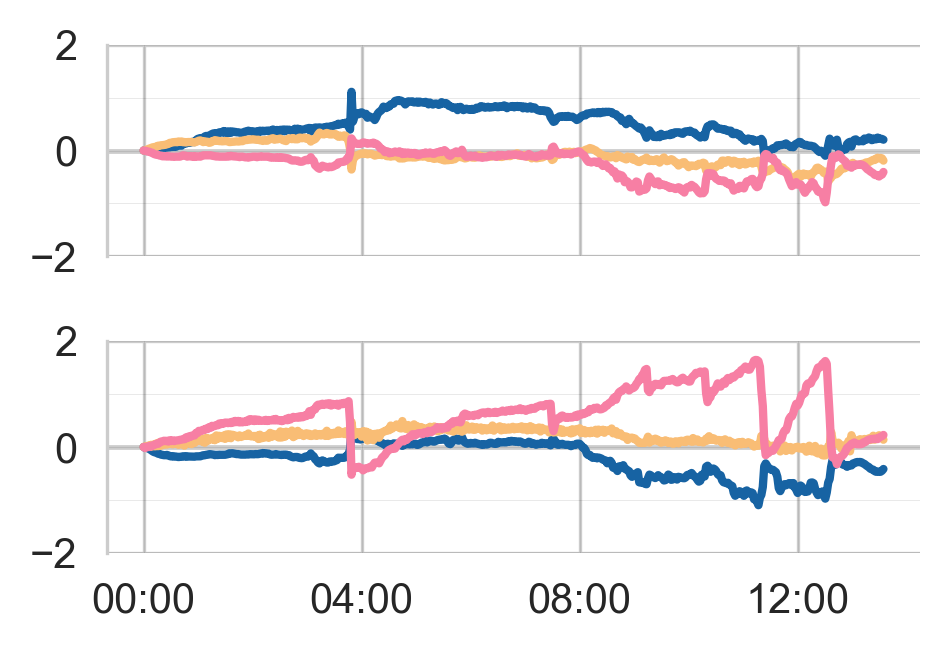

In [13]:
def get_timeformat(seconds):
    m, s = divmod(seconds, 60)
    string = f'{m:02d}:{s:02d}'
    return string

fig, axes = plt.subplots(2,1,figsize=(3.5,2.2), dpi=300, sharex=True)

color_list = ["#1763a3","#f9bd75","#f77fa4","#1763a3","#f9bd75","#f77fa4"]
trans_offset = 2
for i in range(0,3):
    axes[1].plot(motion_params[:,i], lw=2, zorder=100, c=color_list[i])
    axes[1].set_ylim(-trans_offset, trans_offset)
    axes[1].set_yticks([-trans_offset,0,trans_offset])

rot_offset = 2
for i in range(3,6):
    axes[0].plot(np.rad2deg(motion_params[:,i]), lw=2, zorder=100, c=color_list[i])
    axes[0].set_ylim(-rot_offset, rot_offset)
    axes[0].set_yticks([-rot_offset,0,rot_offset])

TR = 1.6
xticks = np.array([0,240,480,720])
axes[1].set_xticks(xticks/TR)
axes[1].set_xticklabels([get_timeformat(s) for s in xticks])

for ax in axes:
    for i in [-2+0.02, -1, 0, 1, 2]:
        ax.axhline(y=i, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    for xt in xticks:
        ax.axvline(x=xt/TR, color='k', linestyle='-', alpha=0.1, lw=0.2, zorder=2)
    ax.axhline(y=0, color='k', linestyle='-', alpha=1.0, lw=0.8, zorder=0)
    ax.spines[['right', 'top','bottom']].set_visible(False)
plt.subplots_adjust(hspace=0.4)

for ax in axes.flatten():
    for tick in ax.get_yticklabels():
        tick.set_fontname("Arial")
    for tick in ax.get_xticklabels():
        tick.set_fontname("Arial")